In [1]:
import pandas as pd

sheets = pd.read_excel("indicatorsMY_v02.xlsx", sheet_name=None)

# Vérifie les noms des feuilles
print(sheets.keys())

# Exemple : afficher les premières lignes de la feuille 'Alternatives'
df = sheets['Alternatives']
df.shape


dict_keys(['Alternatives', 'Market_Indicators', 'Price_Level_BTC', 'Open_Interests_Futures', 'Money_Supply', 'Central_Banks_Balance_Sheets', 'Central_Banks_Policy_Rates', 'TED_Spreads', '3M_Gov__Bonds', 'Yield_Curve', 'Foreign_Exchange', 'Miscellaneous', 'Gross_Domestic_Products', 'Industrial_Production', 'Retail_Sales', 'Inflation', 'Economic Policy Uncertainty', 'News Based Policy Uncertainty', 'Economic_Surprises', 'Semiconductor_Market_Dynamics', 'Sentiment', 'OnChain'])


(136, 5869)

In [2]:
import pandas as pd

#ALLOWED_VARS = {"px_open","px_last","px_high","px_low","px_volume"}
DEFAULT_VAR = "px_last"  # variable par défaut pour les séries type Sentiment/OnChain

df_list = []

for name, sheet in sheets.items():
    sheet = sheet.dropna(how="all", axis=0).dropna(how="all", axis=1)
    if sheet.shape[1] < 3:
        continue

    a1 = str(sheet.columns[0]).strip().lower()
    b1 = str(sheet.columns[1]).strip().upper()

    # ======================================================
    # FORMAT PRIX (Alternatives, etc.)
    # A = Ticker | B = Variable | C.. = Dates
    # On garde UNIQUEMENT px_last
    # ======================================================
    if b1 == "DATES":
        tmp = sheet.copy()
        tmp.columns = ["Ticker", "Variable"] + list(tmp.columns[2:])

        tmp["Variable"] = tmp["Variable"].astype(str).str.strip()
        tmp = tmp[tmp["Variable"] == DEFAULT_VAR]   # <<< FILTRE ICI

        if tmp.empty:
            continue

        melted = tmp.melt(
            id_vars=["Ticker", "Variable"],
            var_name="Date",
            value_name="Value"
        )

    # ======================================================
    # FORMAT FEATURES (Sentiment / OnChain / Indices)
    # A = date | ligne suivante = feature
    # Variable forcée à px_last
    # ======================================================
    elif a1 == "date":
        tmp = sheet.copy()

        tmp = tmp.rename(columns={tmp.columns[0]: "Ticker"})
        tmp.insert(1, "Variable", DEFAULT_VAR)

        melted = tmp.melt(
            id_vars=["Ticker", "Variable"],
            var_name="Date",
            value_name="Value"
        )

    else:
        continue

    # ======================================================
    # Nettoyage
    # ======================================================
    melted["Date"] = pd.to_datetime(melted["Date"], errors="coerce")

    melted["Value"] = (
        melted["Value"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace("-", "", regex=False)
    )
    melted["Value"] = pd.to_numeric(melted["Value"], errors="coerce")

    melted = melted.dropna(subset=["Date", "Value"])

    melted["Ticker"] = melted["Ticker"].astype(str).str.strip()
    melted["Variable"] = DEFAULT_VAR
    melted["Category"] = name

    df_list.append(melted)

# ======================================================
# CONCATÉNATION FINALE
# ======================================================
merged_df = pd.concat(df_list, ignore_index=True)

print("Variables disponibles :", merged_df["Variable"].unique())
print("Nombre de tickers :", merged_df["Ticker"].nunique())


Variables disponibles : ['px_last']
Nombre de tickers : 200


In [3]:
merged_df[['Category', 'Ticker', 'Variable']].drop_duplicates().head(50)


,Category,Ticker,Variable
0,Alternatives,DXY Curncy,px_last
1,Alternatives,XAU Curncy,px_last
2,Alternatives,SPX Index,px_last
3,Alternatives,CCMP Index,px_last
4,Alternatives,RTY Index,px_last
5,Alternatives,CRY Index,px_last
6,Alternatives,SPGSCITR Index,px_last
7,Alternatives,SXXP Index,px_last
8,Alternatives,SHCOMP Index,px_last
14,Alternatives,LUATTRUU Index,px_last


In [4]:
merged_df["Value"].dtype, merged_df["Value"].head()


(dtype('float64'),
 0      76.12601
 1    1057.03000
 2    1076.19000
 3    2139.14000
 4     613.80500
 Name: Value, dtype: float64)

In [5]:
# Nettoyage global de la colonne Value
merged_df["Value"] = (
    merged_df["Value"]
    .astype(str)         # convertir en string
    .str.replace(",", ".")  # remplacer virgules
    .str.replace(" ", "")   # enlever espaces
    .str.replace("-", "")    # remplacer les tirets
)

# Conversion en float
merged_df["Value"] = pd.to_numeric(merged_df["Value"], errors="coerce")


In [6]:
# Nettoyage global de la colonne Value
merged_df["Value"] = (
    merged_df["Value"]
    .astype(str)         # convertir en string
    .str.replace(",", ".")  # remplacer virgules
    .str.replace(" ", "")   # enlever espaces
    .str.replace("-", "")    # remplacer les tirets
)

# Conversion en float
merged_df["Value"] = pd.to_numeric(merged_df["Value"], errors="coerce")


In [7]:
# Convert all dates to datetime
merged_df["Date"] = pd.to_datetime(merged_df["Date"], errors="coerce")

# Force all dates to be timezone-naive
merged_df["Date"] = merged_df["Date"].dt.tz_localize(None)


In [8]:
pivot_df = merged_df.pivot_table(
    index="Date",
    columns="Ticker",
    values="Value",
    aggfunc='mean'   # corrige les doublons mélangés
)

corr = pivot_df.corr()
corr


Ticker,AdrActCnt,BASPTDSP Index,BDIY Index,BOJDPBAL Index,BlkCnt,CCMP Index,CESICNY Index,CESIEUR Index,CESIJPY Index,CESIUSD Index,...,mempool_growth,mempool_size_bytes,miner_revenue_usd,mining_difficulty,n_tx_excl_popular,price_usd,tx_fees_usd,tx_per_block,tx_per_second,utxo_count
Ticker,,,,,,,,,,,,,,,,,,,,,
AdrActCnt,1.000000,0.064268,0.485537,0.012550,0.060275,0.521500,0.054565,0.410257,0.145737,0.296581,...,0.284283,0.281877,0.571241,0.249534,0.392391,-0.093066,0.233444,0.391351,0.274072,0.357221
BASPTDSP Index,0.064268,1.000000,-0.272594,NaN,-0.021686,0.270147,0.031466,0.165858,-0.210168,0.020924,...,0.073628,-0.301102,-0.117918,-0.100492,0.176128,-0.074607,-0.132178,0.203814,0.104114,0.174945
BDIY Index,0.485537,-0.272594,1.000000,0.036977,-0.064568,0.233174,-0.069309,0.080409,0.179934,-0.050504,...,0.012354,0.069579,0.631556,0.258872,0.222923,-0.038660,0.163902,0.221326,0.132556,0.328236
BOJDPBAL Index,0.012550,NaN,0.036977,1.000000,-0.033794,0.576788,-0.117921,-0.148603,-0.136058,-0.169421,...,0.052043,-0.064148,0.394868,0.763197,0.352002,-0.012156,-0.051594,0.344349,0.165110,0.609678
BlkCnt,0.060275,-0.021686,-0.064568,-0.033794,1.000000,-0.111503,-0.101813,-0.059739,-0.098370,0.000024,...,0.040531,-0.027556,0.008288,-0.083498,-0.004266,-0.011690,0.005440,-0.111446,-0.001478,-0.073917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
price_usd,-0.093066,-0.074607,-0.038660,-0.012156,-0.011690,-0.052698,-0.039370,-0.044269,-0.015391,-0.008558,...,-0.025197,-0.010471,-0.047317,-0.033123,-0.065255,1.000000,-0.014509,-0.070128,-0.031075,-0.056166
tx_fees_usd,0.233444,-0.132178,0.163902,-0.051594,0.005440,0.172853,-0.078823,0.139531,0.095097,0.059944,...,0.133237,0.378540,0.411672,0.125381,0.263347,-0.014509,1.000000,0.273559,0.175180,0.194710
tx_per_block,0.391351,0.203814,0.221326,0.344349,-0.111446,0.675226,-0.101149,0.026842,-0.146226,0.007678,...,0.299220,0.471387,0.498025,0.695349,0.877768,-0.070128,0.273559,1.000000,0.510983,0.788411


In [9]:
# Voir toutes les catégories disponibles
print("Catégories disponibles :")
print(merged_df['Category'].unique())
print("\nNombre total de catégories :", merged_df['Category'].nunique())

# Voir tous les tickers disponibles
print("\nTickers disponibles :")
print(merged_df['Ticker'].unique())
print("\nNombre total de tickers :", merged_df['Ticker'].nunique())

# Voir toutes les variables disponibles (px_open, px_last, etc.)
print("\nVariables disponibles :")
print(merged_df['Variable'].unique())
print("\nNombre total de variables :", merged_df['Variable'].nunique())


Catégories disponibles :
['Alternatives' 'Market_Indicators' 'Price_Level_BTC'
 'Open_Interests_Futures' 'Money_Supply' 'Central_Banks_Balance_Sheets'
 'Central_Banks_Policy_Rates' 'TED_Spreads' '3M_Gov__Bonds' 'Yield_Curve'
 'Foreign_Exchange' 'Miscellaneous' 'Gross_Domestic_Products'
 'Industrial_Production' 'Retail_Sales' 'Inflation'
 'Economic Policy Uncertainty' 'News Based Policy Uncertainty'
 'Economic_Surprises' 'Semiconductor_Market_Dynamics' 'Sentiment'
 'OnChain']

Nombre total de catégories : 22

Tickers disponibles :
['DXY Curncy' 'XAU Curncy' 'SPX Index' 'CCMP Index' 'RTY Index'
 'CRY Index' 'SPGSCITR Index' 'SXXP Index' 'SHCOMP Index' 'LUATTRUU Index'
 'LUACTRUU Index' 'LF98TRUU Index' 'NKY Index' 'XETUSD Curncy'
 'XLCUSD Curncy' 'XBNUSD Curncy' 'XRPUSD Curncy' 'XDGUSD Curncy'
 'XADUSD Curncy' 'XSOUSD Curncy' 'VIX Index' 'MOVE Index' 'CVIX Index'
 'RIOT US Equity' 'JPMVXYGL Index' 'MARA US Equity' 'CIFR US Equity'
 'IREN US Equity' 'CORZ US Equity' 'XBTUSD Curncy' 'CFC5Q

In [10]:
print(merged_df['Ticker'].nunique())


200


## PC test


In [11]:
selected_tickers = list(dict.fromkeys([
    # --- On-Chain (Pillar 1) ---
    # Network security & mining
    'HashRate', 'mining_difficulty', 'miner_revenue_usd', 'hashrate_7d_pct',
    # Adoption & usage
    'AdrActCnt', 'TxCnt', 'est_tx_volume_usd', 'avg_block_size',
    # Valuation ratios
    'CapMVRVCur', 'NVT', 'SplyCur',
    
    # --- Macro (Pillar 2) ---
    # Volatility & risk
    'VIX Index', 'MOVE Index',
    # Dollar & currencies
    'DXY Curncy',
    # Equity markets
    'SPX Index', 'CCMP Index', 'RTY Index',
    # Rates & yield curves ("interest rates dominate macro influences")
    'USYC2Y10 Index', 'DEYC2Y10 Index',
    # Liquidity
    'M2 Index', 'FARBAST Index',
    # CFTC positioning
    'TFC2RLFS Index', 'CFC5ROIN Index',
    
    # --- Sentiment (Pillar 3) ---
    'fear_and_greed', 'total_stablecoin_mcap', 'btc_balance_on_exchanges',
    # Google Trends (selected keywords with high potential signal)
    'Bitcoin', 'Coinbase', 'BlackRock Bitcoin', 'Buy Bitcoin',
    
    # --- Crypto Market (altcoin prices — correlated assets) ---
    'XETUSD Curncy', 'XBNUSD Curncy', 'XRPUSD Curncy',
]))


Colonnes sélectionnées (27) : ['HashRate', 'mining_difficulty', 'miner_revenue_usd', 'hashrate_7d_pct', 'AdrActCnt', 'TxCnt', 'est_tx_volume_usd', 'avg_block_size', 'CapMVRVCur', 'NVT', 'SplyCur', 'VIX Index', 'MOVE Index', 'DXY Curncy', 'SPX Index', 'CCMP Index', 'RTY Index', 'USYC2Y10 Index', 'DEYC2Y10 Index', 'M2 Index', 'FARBAST Index', 'TFC2RLFS Index', 'CFC5ROIN Index', 'XETUSD Curncy', 'XBNUSD Curncy', 'XRPUSD Curncy', 'XBTUSD Curncy']
Période : 2010-01-01 00:00:00 → 2025-11-04 00:00:00
Shape brut : (5787, 27)
Shape finale pour PC : (5037, 23)


  0%|          | 0/23 [00:00<?, ?it/s]


ANALYSE COMPLÈTE DES LIENS AVEC XBTUSD Curncy

🔴 CAUSES de XBTUSD Curncy (X → BTC) :
   ✅ miner_revenue_usd ──→ XBTUSD Curncy
   ✅ CapMVRVCur ──→ XBTUSD Curncy
   ✅ XETUSD Curncy ──→ XBTUSD Curncy
   ✅ XBNUSD Curncy ──→ XBTUSD Curncy

🔵 EFFETS de XBTUSD Curncy (BTC → X) :
   Aucun effet direct détecté

🟡 LIENS BIDIRECTIONNELS (X ↔ BTC) :
   Aucun

⚪ LIENS NON ORIENTÉS (X -- BTC) :
   Aucun

RÉSUMÉ : 4 cause(s), 0 effet(s), 0 bidirectionnel(s), 0 non orienté(s)


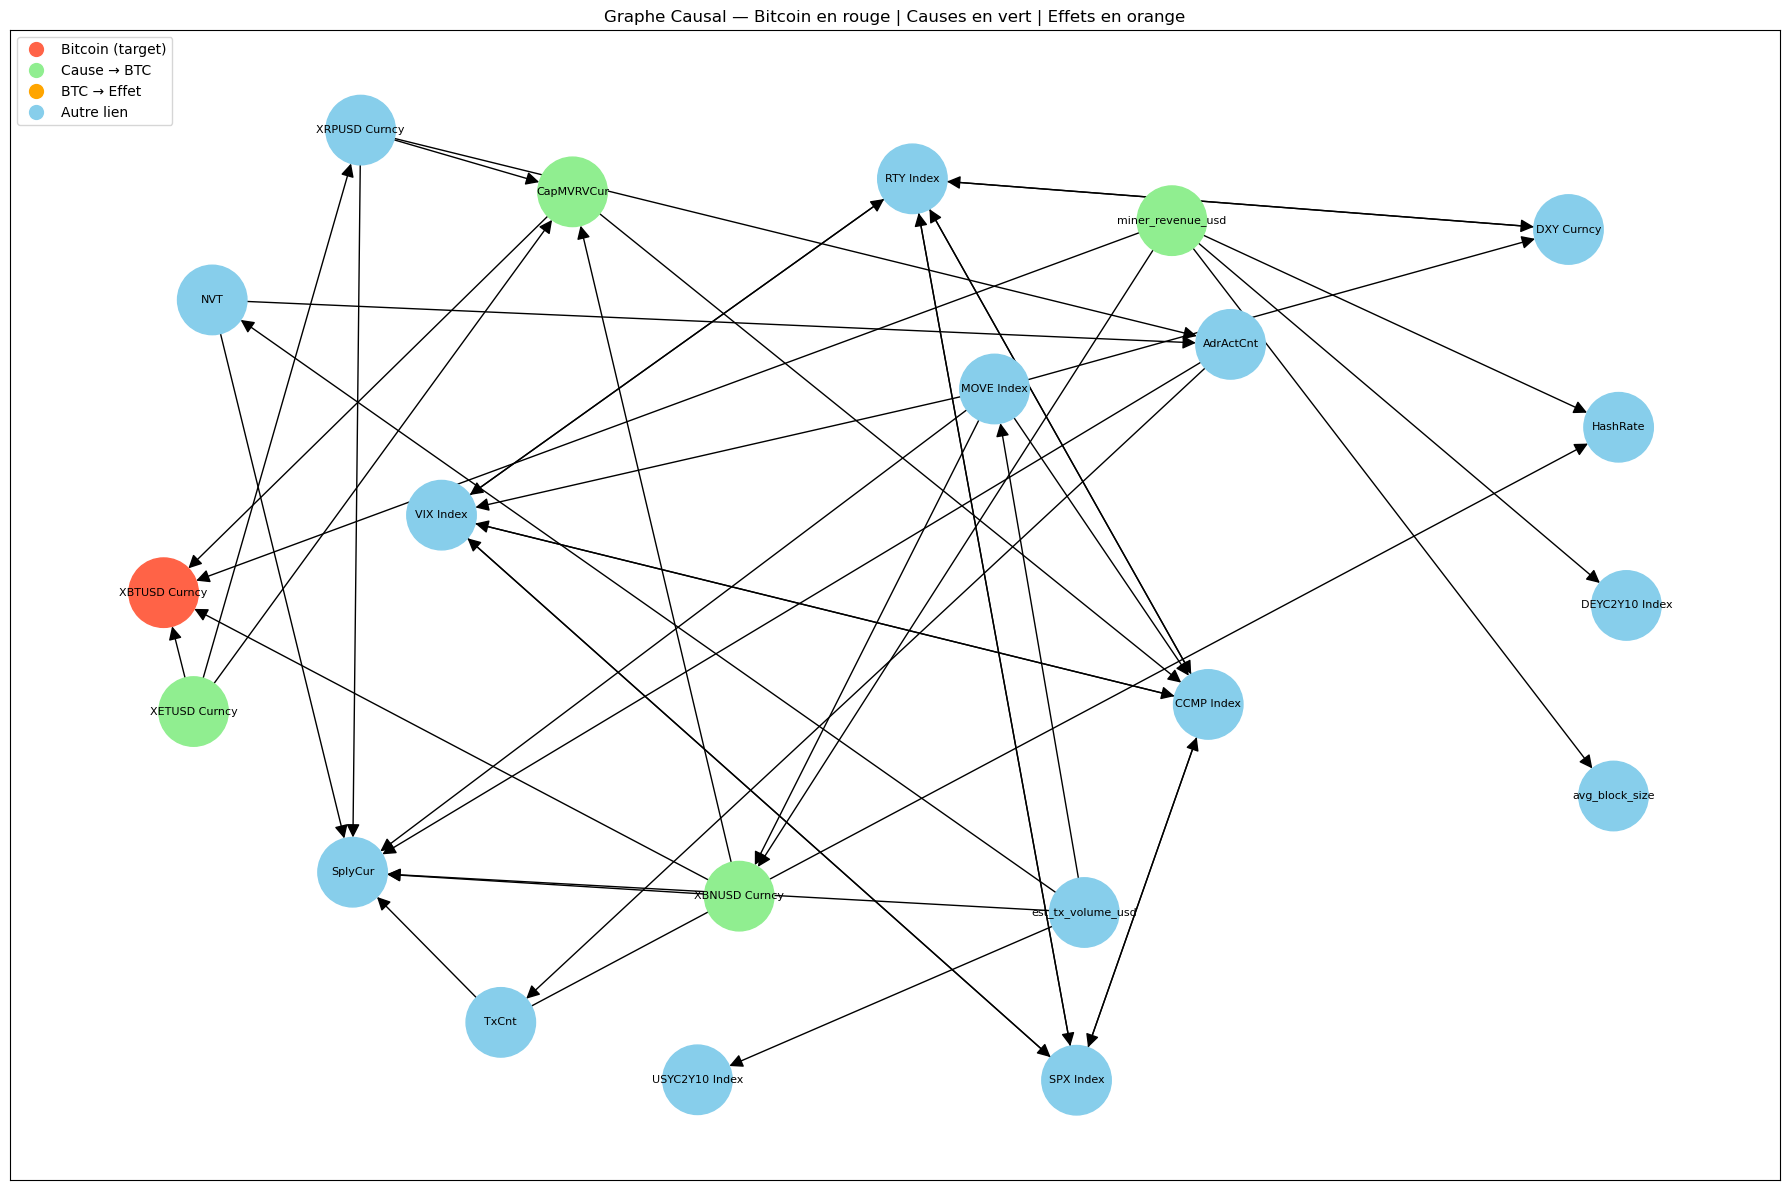

Shape finale : (5037, 23)
Colonnes : ['HashRate', 'mining_difficulty', 'miner_revenue_usd', 'hashrate_7d_pct', 'AdrActCnt', 'TxCnt', 'est_tx_volume_usd', 'avg_block_size', 'CapMVRVCur', 'NVT', 'SplyCur', 'VIX Index', 'MOVE Index', 'DXY Curncy', 'SPX Index', 'CCMP Index', 'RTY Index', 'USYC2Y10 Index', 'DEYC2Y10 Index', 'XETUSD Curncy', 'XBNUSD Curncy', 'XRPUSD Curncy', 'XBTUSD Curncy']


In [18]:
import pandas as pd
import numpy as np
from causallearn.search.ConstraintBased.PC import pc
import networkx as nx
import matplotlib.pyplot as plt

target_ticker = "XBTUSD Curncy"
resample_freq = 'D'

# --- 1. SELECTION ---
selected_tickers = list(dict.fromkeys(selected_tickers))
available_cols = [col for col in selected_tickers if col in pivot_df.columns]
if target_ticker in pivot_df.columns and target_ticker not in available_cols:
    available_cols.append(target_ticker)
available_cols = list(dict.fromkeys(available_cols))

df_sub = pivot_df[available_cols].copy()

# --- 2. FILTRE DATE + RESAMPLE ---
df_sub = df_sub[df_sub.index >= "2010-01-01"]
df_sub = df_sub.resample(resample_freq).mean()
df_sub = df_sub.dropna(thresh=30, axis=1)

cols = pd.Series(df_sub.columns)
for dup in cols[cols.duplicated()].unique():
    dup_idx = cols[cols == dup].index.tolist()
    for suffix_i, idx in enumerate(dup_idx):
        cols[idx] = f"{dup}_{suffix_i}" if suffix_i > 0 else dup
df_sub.columns = cols

print(f"Colonnes sélectionnées ({len(df_sub.columns)}) : {list(df_sub.columns)}")
print(f"Période : {df_sub.index.min()} → {df_sub.index.max()}")
print(f"Shape brut : {df_sub.shape}")

# --- 3. CALCUL DES RENDEMENTS ---
df_returns = df_sub.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan)
df_returns = df_returns.dropna(how='all')
df_returns = df_returns.interpolate(method='linear', limit_direction='both')
df_returns = df_returns.fillna(df_returns.mean())
df_returns = df_returns.dropna(axis=1)

print(f"Shape finale pour PC : {df_returns.shape}")

if target_ticker not in df_returns.columns:
    print(f"ATTENTION : {target_ticker} supprimé car trop de NaN !")
else:
    node_names = list(df_returns.columns)
    btc_idx = node_names.index(target_ticker)

    # --- 4. ALGORITHME PC ---
    try:
        cg = pc(
            df_returns.values,
            alpha=0.05,
            indep_test='fisherz',
            node_names=node_names
        )

        # --- 5. ANALYSE COMPLÈTE DES LIENS ---
        print(f"\n{'='*60}")
        print(f"ANALYSE COMPLÈTE DES LIENS AVEC {target_ticker}")
        print(f"{'='*60}")

        causes   = []  # X → BTC
        effets   = []  # BTC → X
        bidirect = []  # X ↔ BTC
        nonorient= []  # X -- BTC

        for i in range(len(node_names)):
            if i == btc_idx:
                continue

            node_i   = cg.G.nodes[i]
            node_btc = cg.G.nodes[btc_idx]

            edge = cg.G.get_edge(node_i, node_btc)

            if edge is None:
                continue

            ep1 = str(edge.get_endpoint1())  # côté node_i
            ep2 = str(edge.get_endpoint2())  # côté node_btc

            if ep1 == "TAIL" and ep2 == "ARROW":
                causes.append(node_names[i])
            elif ep1 == "ARROW" and ep2 == "TAIL":
                effets.append(node_names[i])
            elif ep1 == "ARROW" and ep2 == "ARROW":
                bidirect.append(node_names[i])
            else:
                nonorient.append(f"{node_names[i]} (ep1={ep1}, ep2={ep2})")

        print(f"\n🔴 CAUSES de {target_ticker} (X → BTC) :")
        if causes:
            for c in causes:
                print(f"   ✅ {c} ──→ {target_ticker}")
        else:
            print("   Aucune cause directe détectée")

        print(f"\n🔵 EFFETS de {target_ticker} (BTC → X) :")
        if effets:
            for e in effets:
                print(f"   📤 {target_ticker} ──→ {e}")
        else:
            print("   Aucun effet direct détecté")

        print(f"\n🟡 LIENS BIDIRECTIONNELS (X ↔ BTC) :")
        if bidirect:
            for b in bidirect:
                print(f"   🔄 {b} ←──→ {target_ticker}")
        else:
            print("   Aucun")

        print(f"\n⚪ LIENS NON ORIENTÉS (X -- BTC) :")
        if nonorient:
            for n in nonorient:
                print(f"   ── {n}")
        else:
            print("   Aucun")

        print(f"\n{'='*60}")
        print(f"RÉSUMÉ : {len(causes)} cause(s), {len(effets)} effet(s), "
              f"{len(bidirect)} bidirectionnel(s), {len(nonorient)} non orienté(s)")
        print(f"{'='*60}")

        # --- 6. VISUALISATION ---
        """
        def plot_dag(adj_matrix, nodes):
            G = nx.DiGraph()
            for i in range(len(nodes)):
                for j in range(len(nodes)):
                    if adj_matrix[i, j] == -1:
                        G.add_edge(nodes[i], nodes[j])

            node_colors = []
            for n in G.nodes():
                if n == target_ticker:
                    node_colors.append("tomato")
                elif n in causes:
                    node_colors.append("lightgreen")
                elif n in effets:
                    node_colors.append("orange")
                else:
                    node_colors.append("skyblue")

            plt.figure(figsize=(18, 12))
            pos = nx.spring_layout(G, seed=42, k=2)
            nx.draw_networkx(
                G, pos=pos,
                with_labels=True,
                node_size=2500,
                node_color=node_colors,
                font_size=8,
                arrows=True,
                arrowsize=20
            )
            legend = [
                plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',    markersize=12, label='Bitcoin (target)'),
                plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='lightgreen', markersize=12, label='Cause → BTC'),
                plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='orange',    markersize=12, label='BTC → Effet'),
                plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='skyblue',   markersize=12, label='Autre lien'),
            ]
            plt.legend(handles=legend, loc='upper left')
            plt.title("Graphe Causal — Bitcoin en rouge | Causes en vert | Effets en orange")
            plt.tight_layout()
            plt.savefig("causal_graph.png", dpi=150)
            plt.show()
"""
        def plot_dag(adj_matrix, nodes):
            G = nx.DiGraph()
            for i in range(len(nodes)):
                for j in range(len(nodes)):
                    if adj_matrix[i, j] == -1:
                        G.add_edge(nodes[j], nodes[i])
        
            # CORRECTION — utilise les listes déjà calculées par le code d'analyse
            # au lieu de les recalculer depuis le graphe
            node_colors = []
            for n in G.nodes():
                if n == target_ticker:
                    node_colors.append("tomato")
                elif n in causes:        # causes calculées AVANT dans le bloc analyse
                    node_colors.append("lightgreen")
                elif n in effets:        # effets calculés AVANT dans le bloc analyse
                    node_colors.append("orange")
                else:
                    node_colors.append("skyblue")
        
            plt.figure(figsize=(18, 12))
            pos = nx.spring_layout(G, seed=42, k=2)
            nx.draw_networkx(
                G, pos=pos,
                with_labels=True,
                node_size=2500,
                node_color=node_colors,
                font_size=8,
                arrows=True,
                arrowsize=20
            )
            legend = [
                plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',     markersize=12, label='Bitcoin (target)'),
                plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='lightgreen', markersize=12, label='Cause → BTC'),
                plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='orange',     markersize=12, label='BTC → Effet'),
                plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='skyblue',    markersize=12, label='Autre lien'),
            ]
            plt.legend(handles=legend, loc='upper left')
            plt.title("Graphe Causal — Bitcoin en rouge | Causes en vert | Effets en orange")
            plt.tight_layout()
            plt.savefig("causal_graph.png", dpi=150)
            plt.show()
        plot_dag(cg.G.graph, node_names)

    except ValueError as e:
        print(f"Erreur mathématique : {e}")
        print("Conseil : Réduisez le nombre de variables ou augmentez la période de temps.")


# Quelles colonnes ont survécu après dropna ?
print(f"Shape finale : {df_returns.shape}")
print(f"Colonnes : {list(df_returns.columns)}")

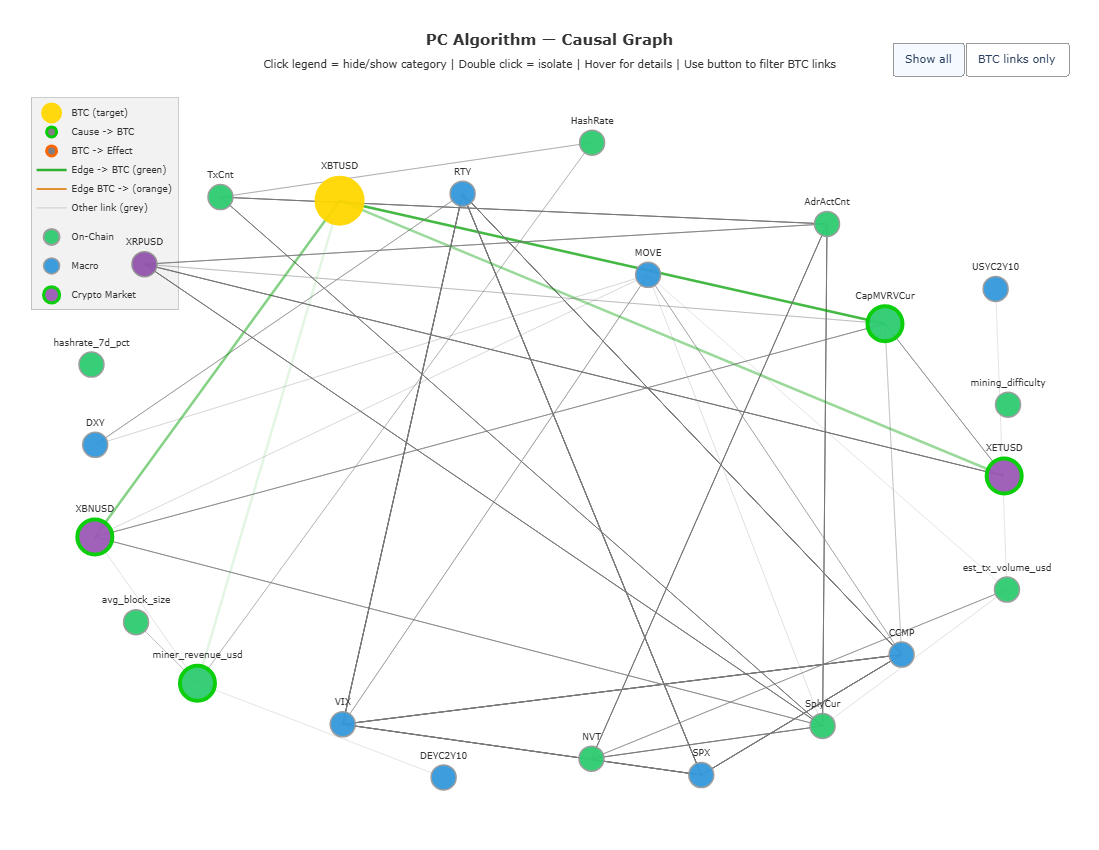

In [28]:
import plotly.graph_objects as go
import networkx as nx
import numpy as np


def plot_dag_no_arrows(adj_matrix, nodes, df_returns, causes, effets, target_ticker):

    G = nx.DiGraph()
    for n in nodes:
        G.add_node(n)
    for i in range(len(nodes)):
        for j in range(len(nodes)):
            if adj_matrix[i, j] == -1:
                G.add_edge(nodes[j], nodes[i])

    btc_neighbors = set(G.predecessors(target_ticker)) | set(G.successors(target_ticker))
    btc_neighbors.add(target_ticker)

    pos = nx.spring_layout(G, seed=42, k=2.5)
    # pos[target_ticker] = np.array([0.0, 1.2])
    corr_matrix = np.abs(np.corrcoef(df_returns.values.T))

    all_traces = []
    vis_all = []
    vis_btc_only = []

    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        idx_u = nodes.index(u) if u in nodes else -1
        idx_v = nodes.index(v) if v in nodes else -1
        weight = corr_matrix[idx_u, idx_v] if idx_u >= 0 and idx_v >= 0 else 0.3
        alpha = max(0.1, min(1.0, weight * 1.5))
        cat_u, cat_v = get_category(u), get_category(v)
        is_btc_edge = (u == target_ticker or v == target_ticker)

        if v == target_ticker:
            rgba = f"rgba(0, 160, 0, {alpha})"; width = 2.5
        elif u == target_ticker:
            rgba = f"rgba(220, 120, 0, {alpha})"; width = 2.0
        else:
            rgba = f"rgba(120, 120, 120, {alpha})"; width = 1.0

        if cat_u == "BTC (target)":
            edge_groups = [cat_v]
        elif cat_v == "BTC (target)":
            edge_groups = [cat_u]
        else:
            edge_groups = [cat_u, cat_v]

        for grp in edge_groups:
            all_traces.append(go.Scatter(
                x=[x0, x1, None], y=[y0, y1, None],
                mode='lines', line=dict(width=width, color=rgba),
                hoverinfo='none', showlegend=False, legendgroup=grp,
            ))
            vis_all.append(True)
            vis_btc_only.append(is_btc_edge)

    for cat, color in CATEGORY_COLORS.items():
        cat_nodes = [n for n in G.nodes() if get_category(n) == cat]
        if not cat_nodes:
            continue
        cx, cy, csizes, ctext, chover, cborders, cborder_w = [], [], [], [], [], [], []
        for node in cat_nodes:
            x, y = pos[node]
            cx.append(x); cy.append(y)
            in_e = list(G.predecessors(node))
            out_e = list(G.successors(node))
            chover.append(
                f"<b>{node}</b><br>"
                f"Category : {cat}<br>"
                f"Receives from : {len(in_e)} nodes<br>"
                f"Sends to : {len(out_e)} nodes<br>"
                f"Connections : {', '.join(in_e + out_e) if in_e + out_e else 'none'}"
            )
            ctext.append(node.replace(" Index", "").replace(" Curncy", ""))
            if node == target_ticker:
                csizes.append(45); cborders.append("#FFD700"); cborder_w.append(5)
            elif node in causes:
                csizes.append(35); cborders.append("#00CC00"); cborder_w.append(4)
            elif node in effets:
                csizes.append(35); cborders.append("#FF6600"); cborder_w.append(4)
            elif node in bidirect:
                csizes.append(35); cborders.append("#CC00CC"); cborder_w.append(4)
            else:
                csizes.append(25); cborders.append("#999999"); cborder_w.append(1.5)

        has_btc_node = any(n in btc_neighbors for n in cat_nodes)
        lg = '_noclick' if cat == "BTC (target)" else cat
        all_traces.append(go.Scatter(
            x=cx, y=cy, mode='markers+text', name=cat,
            text=ctext, textposition='top center',
            textfont=dict(size=9, color='#333333'),
            hovertext=chover, hoverinfo='text',
            marker=dict(size=csizes, color=color,
                        line=dict(color=cborders, width=cborder_w), opacity=0.95),
            legendgroup=lg, showlegend=True,
        ))
        vis_all.append(True)
        vis_btc_only.append(True if cat == "BTC (target)" or has_btc_node else False)

    for trace in [
        go.Scatter(x=[None], y=[None], mode='markers',
                   marker=dict(size=10, color='gray', line=dict(color='#00CC00', width=3)),
                   name='Cause -> BTC', showlegend=True, legendgroup='_noclick'),
        go.Scatter(x=[None], y=[None], mode='markers',
                   marker=dict(size=10, color='gray', line=dict(color='#FF6600', width=3)),
                   name='BTC -> Effect', showlegend=True, legendgroup='_noclick'),
        go.Scatter(x=[None], y=[None], mode='lines',
                   line=dict(color='rgba(0,160,0,0.8)', width=2.5),
                   name='Edge -> BTC (green)', showlegend=True, legendgroup='_noclick'),
        go.Scatter(x=[None], y=[None], mode='lines',
                   line=dict(color='rgba(220,120,0,0.8)', width=2),
                   name='Edge BTC -> (orange)', showlegend=True, legendgroup='_noclick'),
        go.Scatter(x=[None], y=[None], mode='lines',
                   line=dict(color='rgba(120,120,120,0.3)', width=1),
                   name='Other link (grey)', showlegend=True, legendgroup='_noclick'),
    ]:
        all_traces.append(trace)
        vis_all.append(True)
        vis_btc_only.append(True)

    fig = go.Figure(
        data=all_traces,
        layout=go.Layout(
            title=dict(
                text=("<b>PC Algorithm — Causal Graph</b><br>"
                      "<sub>Click legend = hide/show category | "
                      "Double click = isolate | Hover for details | "
                      "Use button to filter BTC links</sub>"),
                font=dict(size=15, color='#333333'), x=0.5),
            paper_bgcolor='white', plot_bgcolor='white', showlegend=True,
            legend=dict(bgcolor='rgba(0,0,0,0.05)', bordercolor='rgba(0,0,0,0.2)',
                        borderwidth=1, font=dict(color='#333333', size=9),
                        x=0.01, y=0.99, groupclick='togglegroup'),
            hovermode='closest',
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            margin=dict(l=20, r=20, t=90, b=20), height=850,
            updatemenus=[dict(
                type="buttons", direction="left",
                x=0.99, y=1.02, xanchor="right", yanchor="bottom",
                buttons=[
                    dict(label="Show all", method="update",
                         args=[{"visible": vis_all}]),
                    dict(label="BTC links only", method="update",
                         args=[{"visible": vis_btc_only}]),
                ],
                bgcolor="white", bordercolor="#999", font=dict(size=11),
            )],
        )
    )
    import webbrowser, os
    filepath = os.path.abspath("causal_graph_no_arrows.html")
    fig.write_html(filepath, include_plotlyjs=True)
    webbrowser.open("file://" + filepath)
    fig.show()

plot_dag_no_arrows(cg.G.graph, node_names, df_returns, causes, effets, target_ticker)

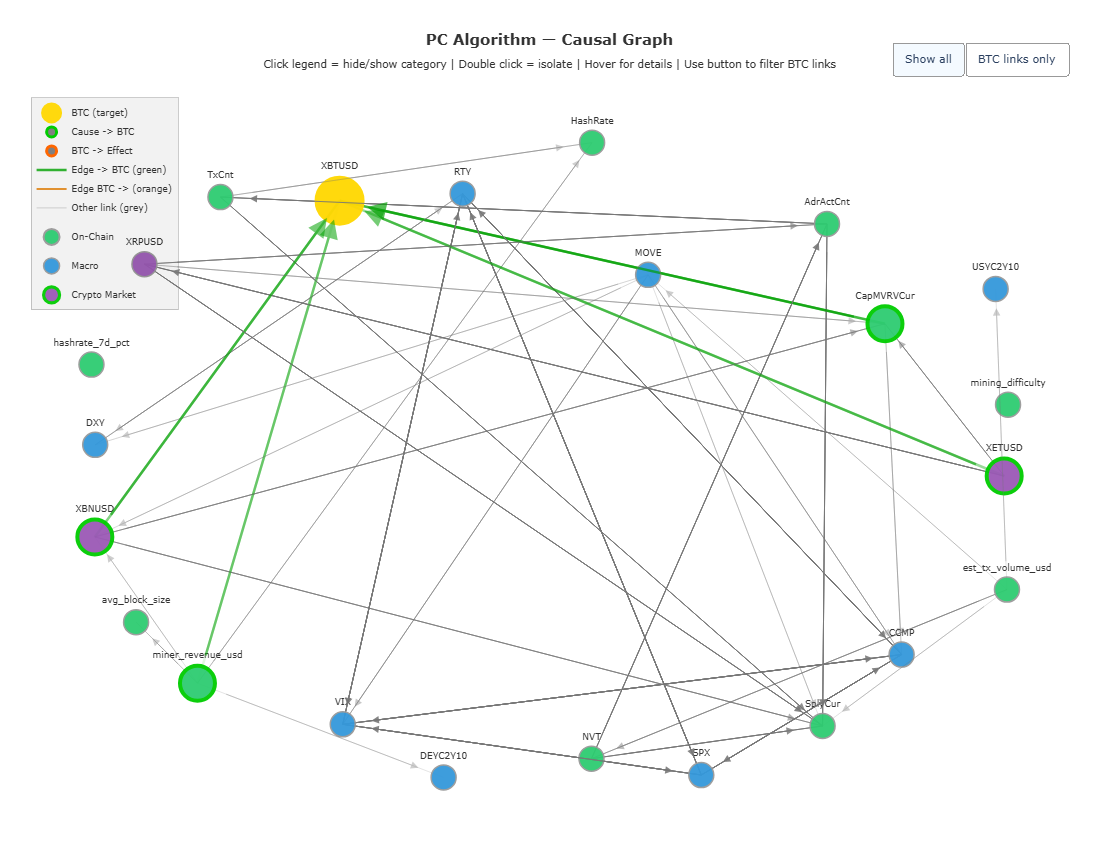

In [27]:
import plotly.graph_objects as go
import networkx as nx
import numpy as np

CATEGORY_MAP = {
    'HashRate': 'On-Chain', 'mining_difficulty': 'On-Chain',
    'miner_revenue_usd': 'On-Chain', 'hashrate_7d_pct': 'On-Chain',
    'AdrActCnt': 'On-Chain', 'TxCnt': 'On-Chain', 'TxTfrCnt': 'On-Chain',
    'est_tx_volume_usd': 'On-Chain', 'avg_block_size': 'On-Chain',
    'tx_fees_usd': 'On-Chain', 'CapMVRVCur': 'On-Chain', 'NVT': 'On-Chain',
    'NVT_Signal': 'On-Chain', 'SplyCur': 'On-Chain',
    'VIX Index': 'Macro', 'MOVE Index': 'Macro', 'DXY Curncy': 'Macro',
    'XAU Curncy': 'Macro', 'SPX Index': 'Macro', 'CCMP Index': 'Macro',
    'RTY Index': 'Macro', 'USYC2Y10 Index': 'Macro', 'DEYC2Y10 Index': 'Macro',
    'M2 Index': 'Macro', 'FARBAST Index': 'Macro',
    'TFC2RLFS Index': 'Macro', 'CFC5ROIN Index': 'Macro',
    'fear_and_greed': 'Sentiment', 'total_stablecoin_mcap': 'Sentiment',
    'btc_balance_on_exchanges': 'Sentiment', 'btc_dominance_proxy': 'Sentiment',
    'Bitcoin': 'Sentiment', 'Coinbase': 'Sentiment',
    'BlackRock Bitcoin': 'Sentiment', 'Buy Bitcoin': 'Sentiment',
    'XETUSD Curncy': 'Crypto Market', 'XBNUSD Curncy': 'Crypto Market',
    'XRPUSD Curncy': 'Crypto Market',
    'XBTUSD Curncy': 'BTC (target)',
}
CATEGORY_COLORS = {
    'BTC (target)': '#FFD700', 'On-Chain': '#2ecc71',
    'Macro': '#3498db', 'Sentiment': '#e74c3c', 'Crypto Market': '#9b59b6',
}
def get_category(ticker):
    return CATEGORY_MAP.get(ticker, 'Other')


def plot_dag_arrows(adj_matrix, nodes, df_returns, causes, effets, target_ticker):

    G = nx.DiGraph()
    for n in nodes:
        G.add_node(n)
    for i in range(len(nodes)):
        for j in range(len(nodes)):
            if adj_matrix[i, j] == -1:
                G.add_edge(nodes[j], nodes[i])

    # Nœuds directement connectés à BTC
    btc_neighbors = set(G.predecessors(target_ticker)) | set(G.successors(target_ticker))
    btc_neighbors.add(target_ticker)

    pos = nx.spring_layout(G, seed=42, k=2.5)
    # pos[target_ticker] = np.array([0.0, 1.2])
    corr_matrix = np.abs(np.corrcoef(df_returns.values.T))

    all_traces = []
    arrows_all = []      # toutes les flèches
    arrows_btc_only = []  # flèches connectées à BTC seulement

    # Track visibility per trace
    vis_all = []       # visibility quand "Show all"
    vis_btc_only = []  # visibility quand "BTC links only"

    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        idx_u = nodes.index(u) if u in nodes else -1
        idx_v = nodes.index(v) if v in nodes else -1
        weight = corr_matrix[idx_u, idx_v] if idx_u >= 0 and idx_v >= 0 else 0.3
        alpha = max(0.1, min(1.0, weight * 1.5))
        cat_u, cat_v = get_category(u), get_category(v)

        is_btc_edge = (u == target_ticker or v == target_ticker)

        if v == target_ticker:
            rgba  = f"rgba(0, 160, 0, {alpha})"
            solid = f"rgba(0, 160, 0, {max(alpha, 0.6)})"
            width = 2.5
        elif u == target_ticker:
            rgba  = f"rgba(220, 120, 0, {alpha})"
            solid = f"rgba(220, 120, 0, {max(alpha, 0.6)})"
            width = 2.0
        else:
            rgba  = f"rgba(120, 120, 120, {alpha})"
            solid = f"rgba(120, 120, 120, {max(alpha, 0.4)})"
            width = 1.0

        if cat_u == "BTC (target)":
            edge_groups = [cat_v]
        elif cat_v == "BTC (target)":
            edge_groups = [cat_u]
        else:
            edge_groups = [cat_u, cat_v]

        for grp in edge_groups:
            all_traces.append(go.Scatter(
                x=[x0, x1, None], y=[y0, y1, None],
                mode='lines', line=dict(width=width, color=rgba),
                hoverinfo='none', showlegend=False, legendgroup=grp,
            ))
            vis_all.append(True)
            vis_btc_only.append(is_btc_edge)

        # Arrow
        dx, dy = x1 - x0, y1 - y0
        length = np.sqrt(dx**2 + dy**2)
        if length > 0:
            shrink = 0.06
            arrow = dict(
                x=x1 - (dx/length)*shrink, y=y1 - (dy/length)*shrink,
                ax=x0 + (dx/length)*shrink, ay=y0 + (dy/length)*shrink,
                xref='x', yref='y', axref='x', ayref='y',
                showarrow=True, arrowhead=2, arrowsize=1.5,
                arrowwidth=width, arrowcolor=solid, opacity=0.9,
            )
            arrows_all.append(arrow)
            if is_btc_edge:
                arrows_btc_only.append(arrow)

    # --- NODES ---
    for cat, color in CATEGORY_COLORS.items():
        cat_nodes = [n for n in G.nodes() if get_category(n) == cat]
        if not cat_nodes:
            continue
        cx, cy, csizes, ctext, chover, cborders, cborder_w = [], [], [], [], [], [], []
        for node in cat_nodes:
            x, y = pos[node]
            cx.append(x); cy.append(y)
            in_e = list(G.predecessors(node))
            out_e = list(G.successors(node))
            chover.append(
                f"<b>{node}</b><br>"
                f"Category : {cat}<br>"
                f"Receives from : {len(in_e)} nodes<br>"
                f"Sends to : {len(out_e)} nodes<br>"
                f"Connections : {', '.join(in_e + out_e) if in_e + out_e else 'none'}"
            )
            ctext.append(node.replace(" Index", "").replace(" Curncy", ""))
            if node == target_ticker:
                csizes.append(45); cborders.append("#FFD700"); cborder_w.append(5)
            elif node in causes:
                csizes.append(35); cborders.append("#00CC00"); cborder_w.append(4)
            elif node in effets:
                csizes.append(35); cborders.append("#FF6600"); cborder_w.append(4)
            elif node in bidirect:
                csizes.append(35); cborders.append("#CC00CC"); cborder_w.append(4)
            else:
                csizes.append(25); cborders.append("#999999"); cborder_w.append(1.5)

        # Est-ce que cette catégorie a au moins 1 nœud connecté à BTC ?
        has_btc_node = any(n in btc_neighbors for n in cat_nodes)

        lg = '_noclick' if cat == "BTC (target)" else cat
        all_traces.append(go.Scatter(
            x=cx, y=cy, mode='markers+text', name=cat,
            text=ctext, textposition='top center',
            textfont=dict(size=9, color='#333333'),
            hovertext=chover, hoverinfo='text',
            marker=dict(size=csizes, color=color,
                        line=dict(color=cborders, width=cborder_w), opacity=0.95),
            legendgroup=lg, showlegend=True,
        ))
        vis_all.append(True)
        # Pour BTC-only : montrer BTC toujours, et les catégories qui ont des voisins BTC
        vis_btc_only.append(True if cat == "BTC (target)" or has_btc_node else False)

    # --- LEGEND ROLES ---
    for trace in [
        go.Scatter(x=[None], y=[None], mode='markers',
                   marker=dict(size=10, color='gray', line=dict(color='#00CC00', width=3)),
                   name='Cause -> BTC', showlegend=True, legendgroup='_noclick'),
        go.Scatter(x=[None], y=[None], mode='markers',
                   marker=dict(size=10, color='gray', line=dict(color='#FF6600', width=3)),
                   name='BTC -> Effect', showlegend=True, legendgroup='_noclick'),
        go.Scatter(x=[None], y=[None], mode='lines',
                   line=dict(color='rgba(0,160,0,0.8)', width=2.5),
                   name='Edge -> BTC (green)', showlegend=True, legendgroup='_noclick'),
        go.Scatter(x=[None], y=[None], mode='lines',
                   line=dict(color='rgba(220,120,0,0.8)', width=2),
                   name='Edge BTC -> (orange)', showlegend=True, legendgroup='_noclick'),
        go.Scatter(x=[None], y=[None], mode='lines',
                   line=dict(color='rgba(120,120,120,0.3)', width=1),
                   name='Other link (grey)', showlegend=True, legendgroup='_noclick'),
    ]:
        all_traces.append(trace)
        vis_all.append(True)
        vis_btc_only.append(True)

    fig = go.Figure(
        data=all_traces,
        layout=go.Layout(
            title=dict(
                text=("<b>PC Algorithm — Causal Graph</b><br>"
                      "<sub>Click legend = hide/show category | "
                      "Double click = isolate | Hover for details | "
                      "Use button to filter BTC links</sub>"),
                font=dict(size=15, color='#333333'), x=0.5),
            paper_bgcolor='white', plot_bgcolor='white', showlegend=True,
            legend=dict(bgcolor='rgba(0,0,0,0.05)', bordercolor='rgba(0,0,0,0.2)',
                        borderwidth=1, font=dict(color='#333333', size=9),
                        x=0.01, y=0.99, groupclick='togglegroup'),
            hovermode='closest',
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            margin=dict(l=20, r=20, t=90, b=20), height=850,
            annotations=arrows_all,
            updatemenus=[dict(
                type="buttons",
                direction="left",
                x=0.99, y=1.02,
                xanchor="right", yanchor="bottom",
                buttons=[
                    dict(
                        label="Show all",
                        method="update",
                        args=[{"visible": vis_all},
                              {"annotations": arrows_all}],
                    ),
                    dict(
                        label="BTC links only",
                        method="update",
                        args=[{"visible": vis_btc_only},
                              {"annotations": arrows_btc_only}],
                    ),
                ],
                bgcolor="white",
                bordercolor="#999",
                font=dict(size=11),
            )],
        )
    )
    import webbrowser, os
    filepath = os.path.abspath("causal_graph_arrows.html")
    fig.write_html(filepath, include_plotlyjs=True)
    webbrowser.open("file://" + filepath)
    fig.show()

plot_dag_arrows(cg.G.graph, node_names, df_returns, causes, effets, target_ticker)

## Conclusion — PC Algorithm Causal Graph

### How to use the interactive graph

- **Single click** on a legend category (On-Chain, Macro, Crypto Market, Sentiment) to hide/show that category and all its connected edges.
- **Double click** on a category to isolate it (hide everything else). Double click again to restore all.
- **Hover** over any node to see its details: category, number of incoming/outgoing connections, and the list of connected nodes.
- **BTC (target)** and the role legend items (Cause -> BTC, Effect, Edge colors) are not toggleable — they stay visible at all times.
- Two versions of the graph are provided: one with directional arrows and one with simple lines.

### What was done

1. **Data preparation**: Weekly resampling, forward-fill only (no look-ahead bias), stationarity transforms (diff() for bounded features like VIX/fear_and_greed, pct_change() for prices/volumes), truncation to common date range.

2. **PC Algorithm** (alpha=0.05, Fisher-Z test): Constraint-based causal discovery that tests conditional independence between all variable pairs. Edges represent statistically significant causal relationships that survive conditioning on other variables.

3. **Graph construction**: Nodes are colored by Vaissie pillar (On-Chain, Macro, Sentiment, Crypto Market). Node borders indicate causal role (green = cause of BTC, orange = effect of BTC, magenta = bidirectional). Edge colors indicate direction (green = towards BTC, orange = from BTC, grey = between other variables). Edge transparency reflects correlation strength.

4. **Key findings**: The PC algorithm identifies On-Chain metrics (CapMVRVCur, miner_revenue_usd, NVT_Signal) and crypto market prices (XETUSD, XBNUSD) as the strongest causal drivers of BTC. Macro variables appear connected to BTC but mostly through indirect paths. Sentiment features show no direct causal edges — their information is likely absorbed by other variables in conditional independence tests.

